In [1]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp

from agl_helpers import addNoise, recoverDynamics

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)


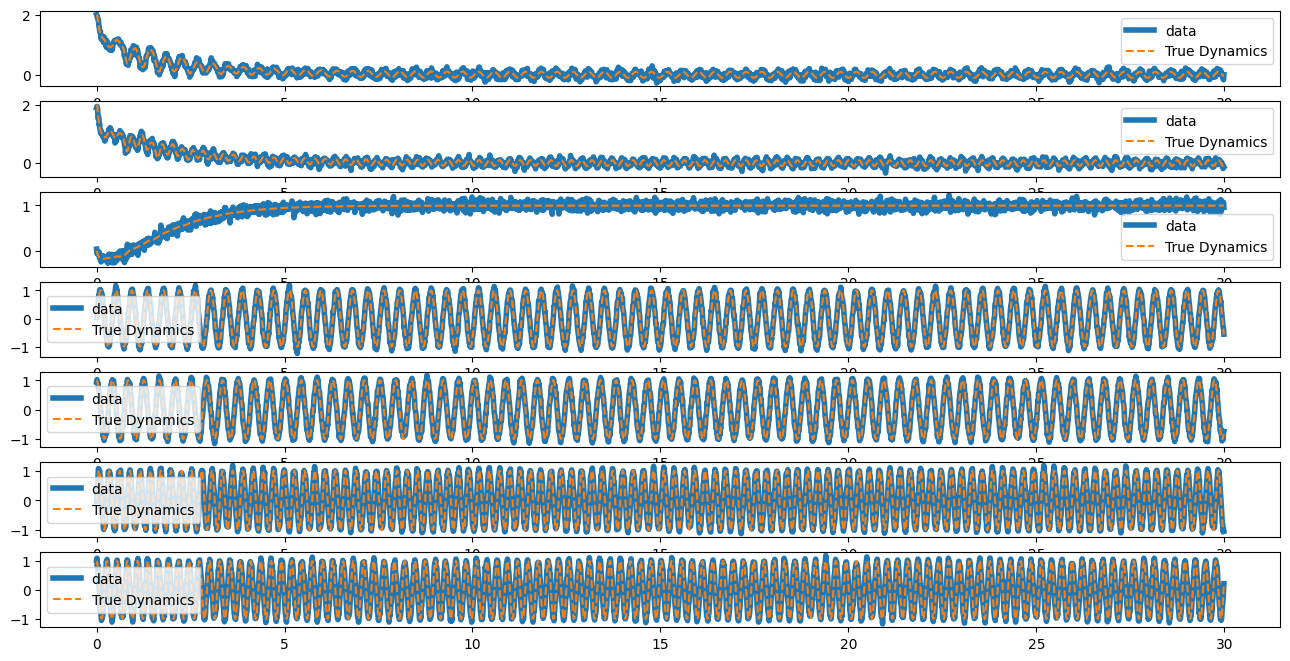

In [ ]:
t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
noise_ratio = 0.1

# extremum seeking parameters
alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

def rhs(t, z):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = omega_x*cx
            dcx = -omega_x*mx
            dmy = omega_y*cy
            dcy = -omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [3]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 2),ld=0.05
                         )

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])

recoverDynamics(WSINDy_model)

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
dx0/dt = -0.3121 + (-0.0588)x6 + (1.4677)x4 + (0.4372)x3 + (0.3079)x2 + (0.3518)x1 + (-0.5581)x0
dx1/dt = -0.0629 + (2.1469)x6 + (0.3897)x5 + (-0.0600)x4 + (0.0650)x2 + (-0.4277)x1
dx2/dt = 0.0548 + (0.0744)x6 + (-0.0524)x4 + (0.1118)x3 + (-0.0560)x2 + (1.4140)x1 + (-0.8901)x0
dx3/dt = -0.7568 + (-0.2977)x6 + (0.2197)x5 + (14.8498)x4 + (-0.0502)x3 + (0.7062)x2 + (-1.4600)x1 + (2.5565)x0
dx4/dt = 0.4403 + (-0.4635)x6 + (0.6548)x5 + (-0.0822)x4 + (-15.0453)x3 + (-0.4738)x2 + (-4.7306)x1 + (4.5660)x0
dx5/dt = -0.6235 + (21.4868)x6 + (0.2452)x5 + (-0.0652)x4 + (0.1024)x3 + (0.6488)x2 + (-1.2702)x1 + (2.2980)x0
dx6/dt = 2.1987 + (-0.2230)x6 + (-21.4057)x5 + (-0.4144)x3 + (-2.1682)x2 + (-7.4805)x1 + (5.3177)x0


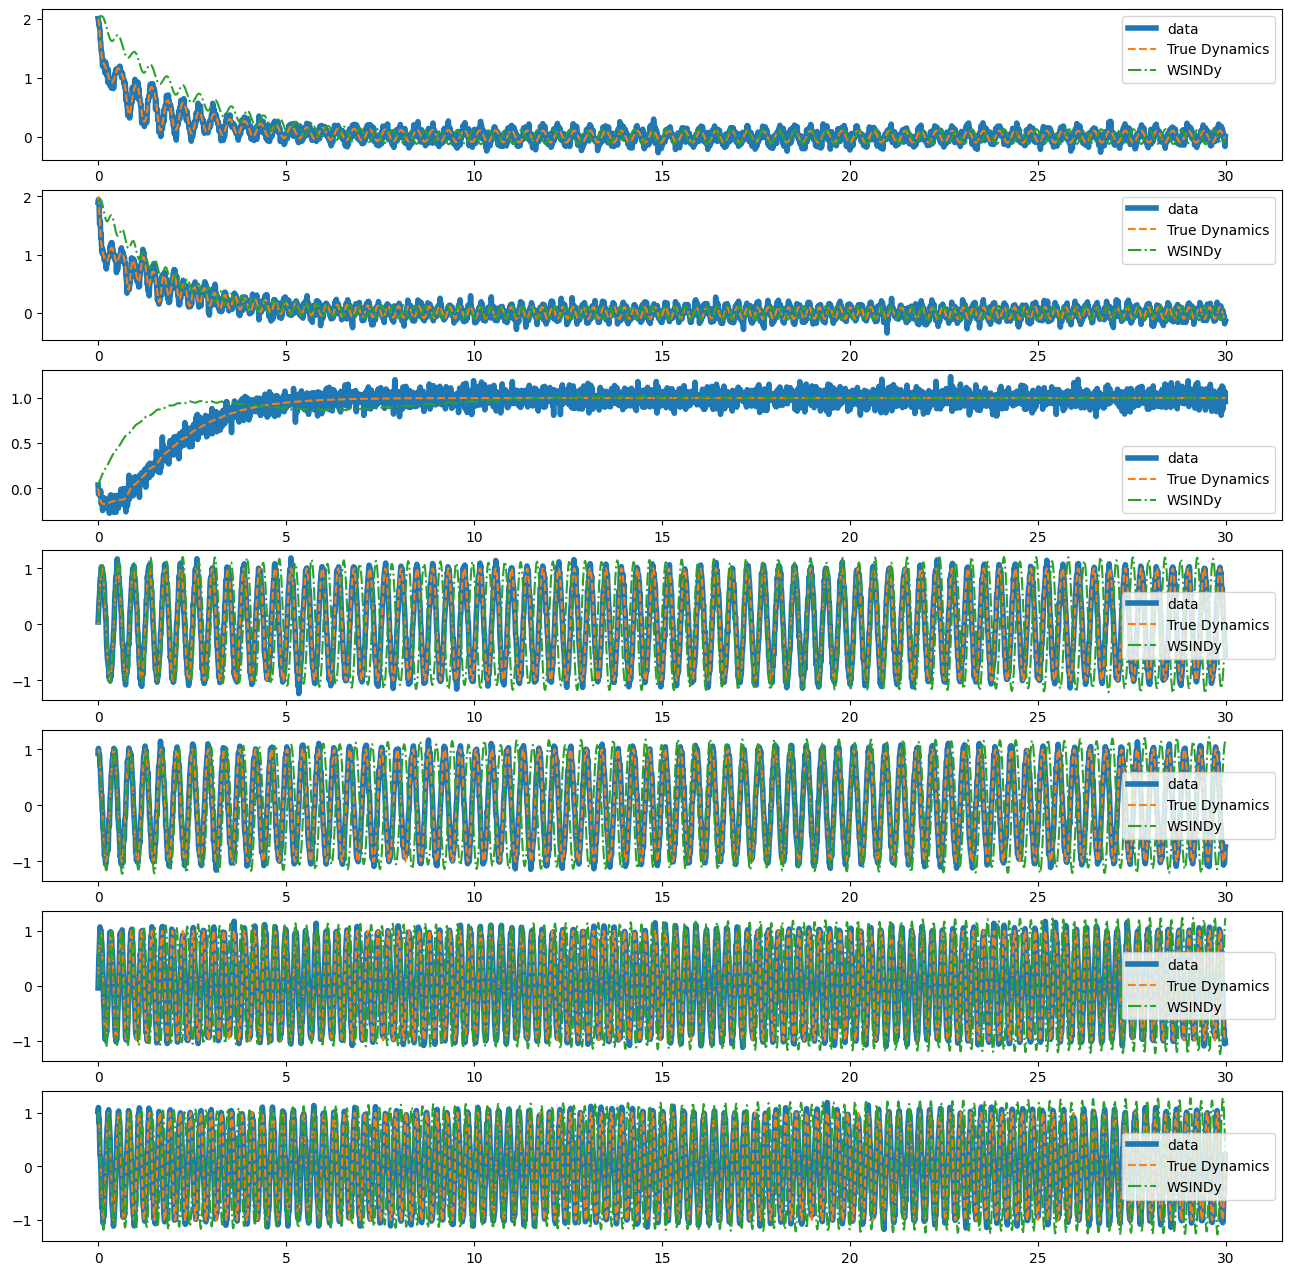

In [4]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    
    c = c + 1
    plt.legend()